In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("dataset_hrv.csv")
df.head()

,record,window_start_sec,window_end_sec,mean_ibi,median_ibi,sdnn,rmssd,cv,mean_sd,std_sd,tpr,sd1,sd2,sd1_sd2,label
0,735,0.0,10.0,1090.5000,1084.0,20.2767,31.0576,1.8594,26.2857,33.4550,0.5000,23.6563,16.2070,1.4596,0
1,735,10.0,20.0,1120.0000,1128.0,36.7151,54.6260,3.2781,51.0000,57.2014,0.5714,40.4475,32.5576,1.2423,0
2,735,20.0,30.0,1140.8889,1140.0,29.5146,50.4183,2.5870,41.5000,53.8331,0.5714,38.0657,17.1237,2.2230,0
3,735,30.0,40.0,1116.4444,1108.0,47.8098,61.6117,4.2823,49.0000,65.8657,0.4286,46.5741,49.0144,0.9502,0
4,735,40.0,50.0,1134.2222,1132.0,34.1240,35.5809,3.0086,30.5000,37.3975,0.7143,26.4440,40.3683,0.6551,0


## `eda singkat`

<class 'pandas.DataFrame'>
RangeIndex: 87826 entries, 0 to 87825
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   record            87826 non-null  int64  
 1   window_start_sec  87826 non-null  float64
 2   window_end_sec    87826 non-null  float64
 3   mean_ibi          87826 non-null  float64
 4   median_ibi        87826 non-null  float64
 5   sdnn              87826 non-null  float64
 6   rmssd             87826 non-null  float64
 7   cv                87826 non-null  float64
 8   mean_sd           87826 non-null  float64
 9   std_sd            87826 non-null  float64
 10  tpr               87826 non-null  float64
 11  sd1               87826 non-null  float64
 12  sd2               87826 non-null  float64
 13  sd1_sd2           87826 non-null  float64
 14  label             87826 non-null  int64  
dtypes: float64(13), int64(2)
memory usage: 10.1 MB
None
label
0    53655
1    33668
2      503
Name: c

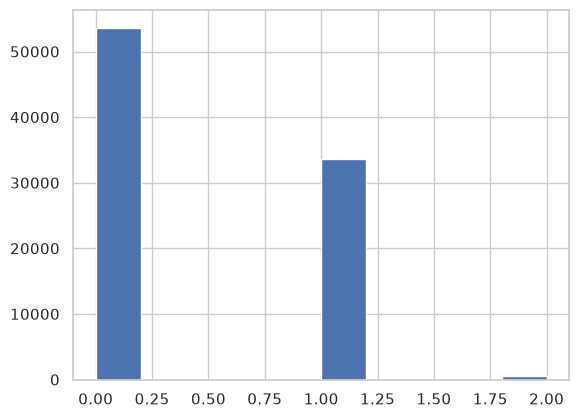

In [62]:
df['label'].hist()
print(df.info())
print(df['label'].value_counts())

In [63]:
df.isnull().sum()

record              0
window_start_sec    0
window_end_sec      0
mean_ibi            0
median_ibi          0
sdnn                0
rmssd               0
cv                  0
mean_sd             0
std_sd              0
tpr                 0
sd1                 0
sd2                 0
sd1_sd2             0
label               0
dtype: int64

In [64]:
df.describe(include='all')

,record,window_start_sec,window_end_sec,mean_ibi,median_ibi,sdnn,rmssd,cv,mean_sd,std_sd,tpr,sd1,sd2,sd1_sd2,label
count,87826.00000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,8.782600e+04,87826.000000
mean,6112.11434,17751.002095,17761.002095,773.749950,769.718580,82.675288,114.497447,11.487689,87.851259,118.937699,0.548933,84.101654,77.887378,8.794524e+02,0.394803
std,2001.59376,10363.455692,10363.455692,173.219256,178.751018,87.037414,123.628699,10.693924,96.043685,129.310728,0.182245,91.436493,85.586731,2.603096e+05,0.500391
min,735.00000,0.000000,10.000000,348.428600,286.000000,1.500400,1.460600,0.169200,0.533300,1.407500,0.000000,0.995200,0.000000,0.000000e+00,0.000000
25%,4746.00000,8780.000000,8790.000000,619.500000,612.000000,13.548600,15.849300,1.681950,13.090900,16.424900,0.437500,11.614200,14.477725,7.380000e-01,0.000000
50%,6426.00000,17570.000000,17580.000000,769.230800,772.000000,61.151650,82.592200,9.223100,56.615400,85.139150,0.555600,60.202450,55.061900,9.936000e-01,0.000000
75%,7910.00000,26710.000000,26720.000000,912.000000,912.000000,136.206375,189.019500,20.247250,143.200000,195.626450,0.666700,138.328775,125.461425,1.295900e+00,1.000000
max,8455.00000,36810.000000,36820.000000,3962.666700,2140.000000,5910.928600,7249.285800,243.799300,5140.000000,7269.057700,1.000000,5140.000000,6592.310300,7.714393e+07,2.000000


## `eda mendalam`

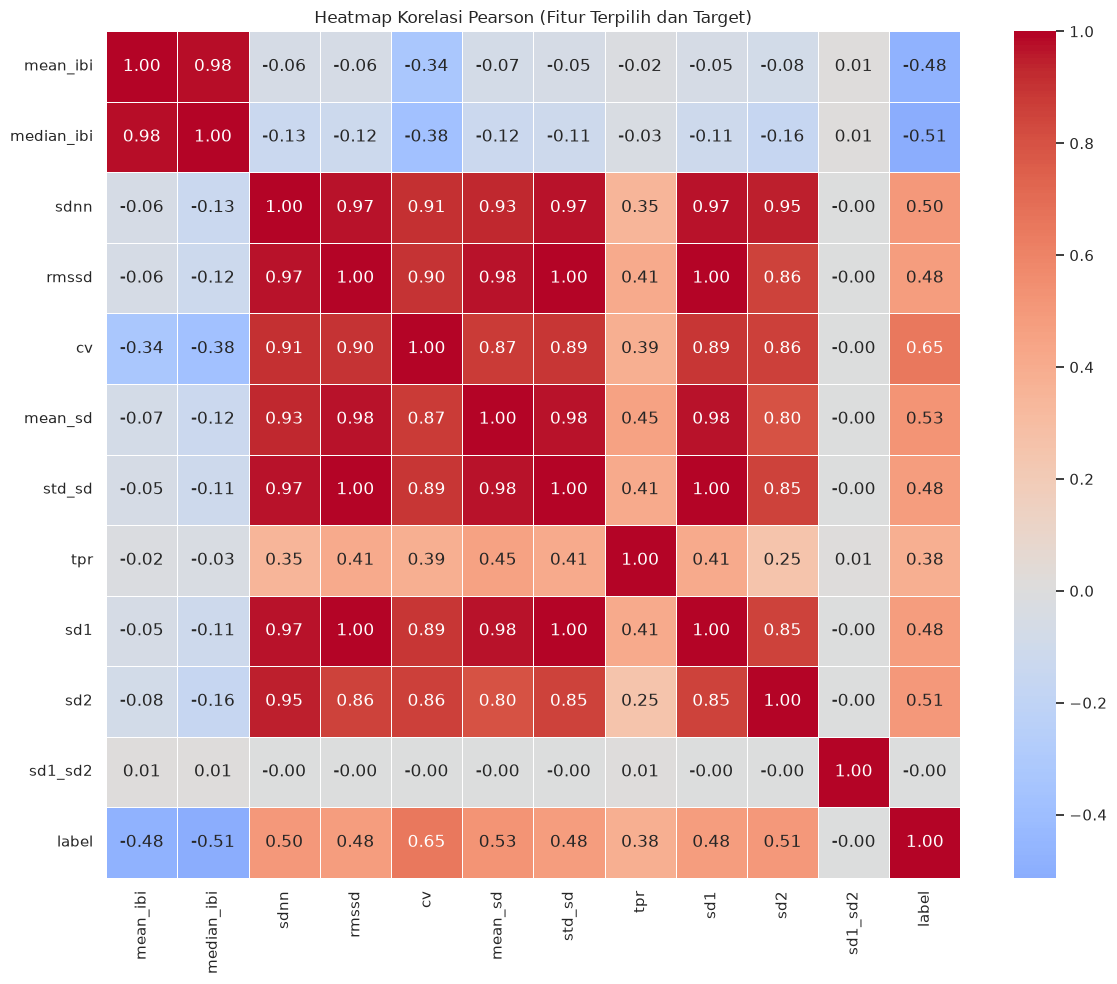

In [65]:
selected_cols = ['mean_ibi', 'median_ibi', 'sdnn', 'rmssd', 'cv', 'mean_sd', 'std_sd', 'tpr', 'sd1', 'sd2', 'sd1_sd2', 'label']
plt.figure(figsize=(12, 10))
sns.heatmap(
    df[selected_cols].corr(method="pearson"),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Heatmap Korelasi Pearson (Fitur Terpilih dan Target)")
plt.tight_layout()
plt.show()

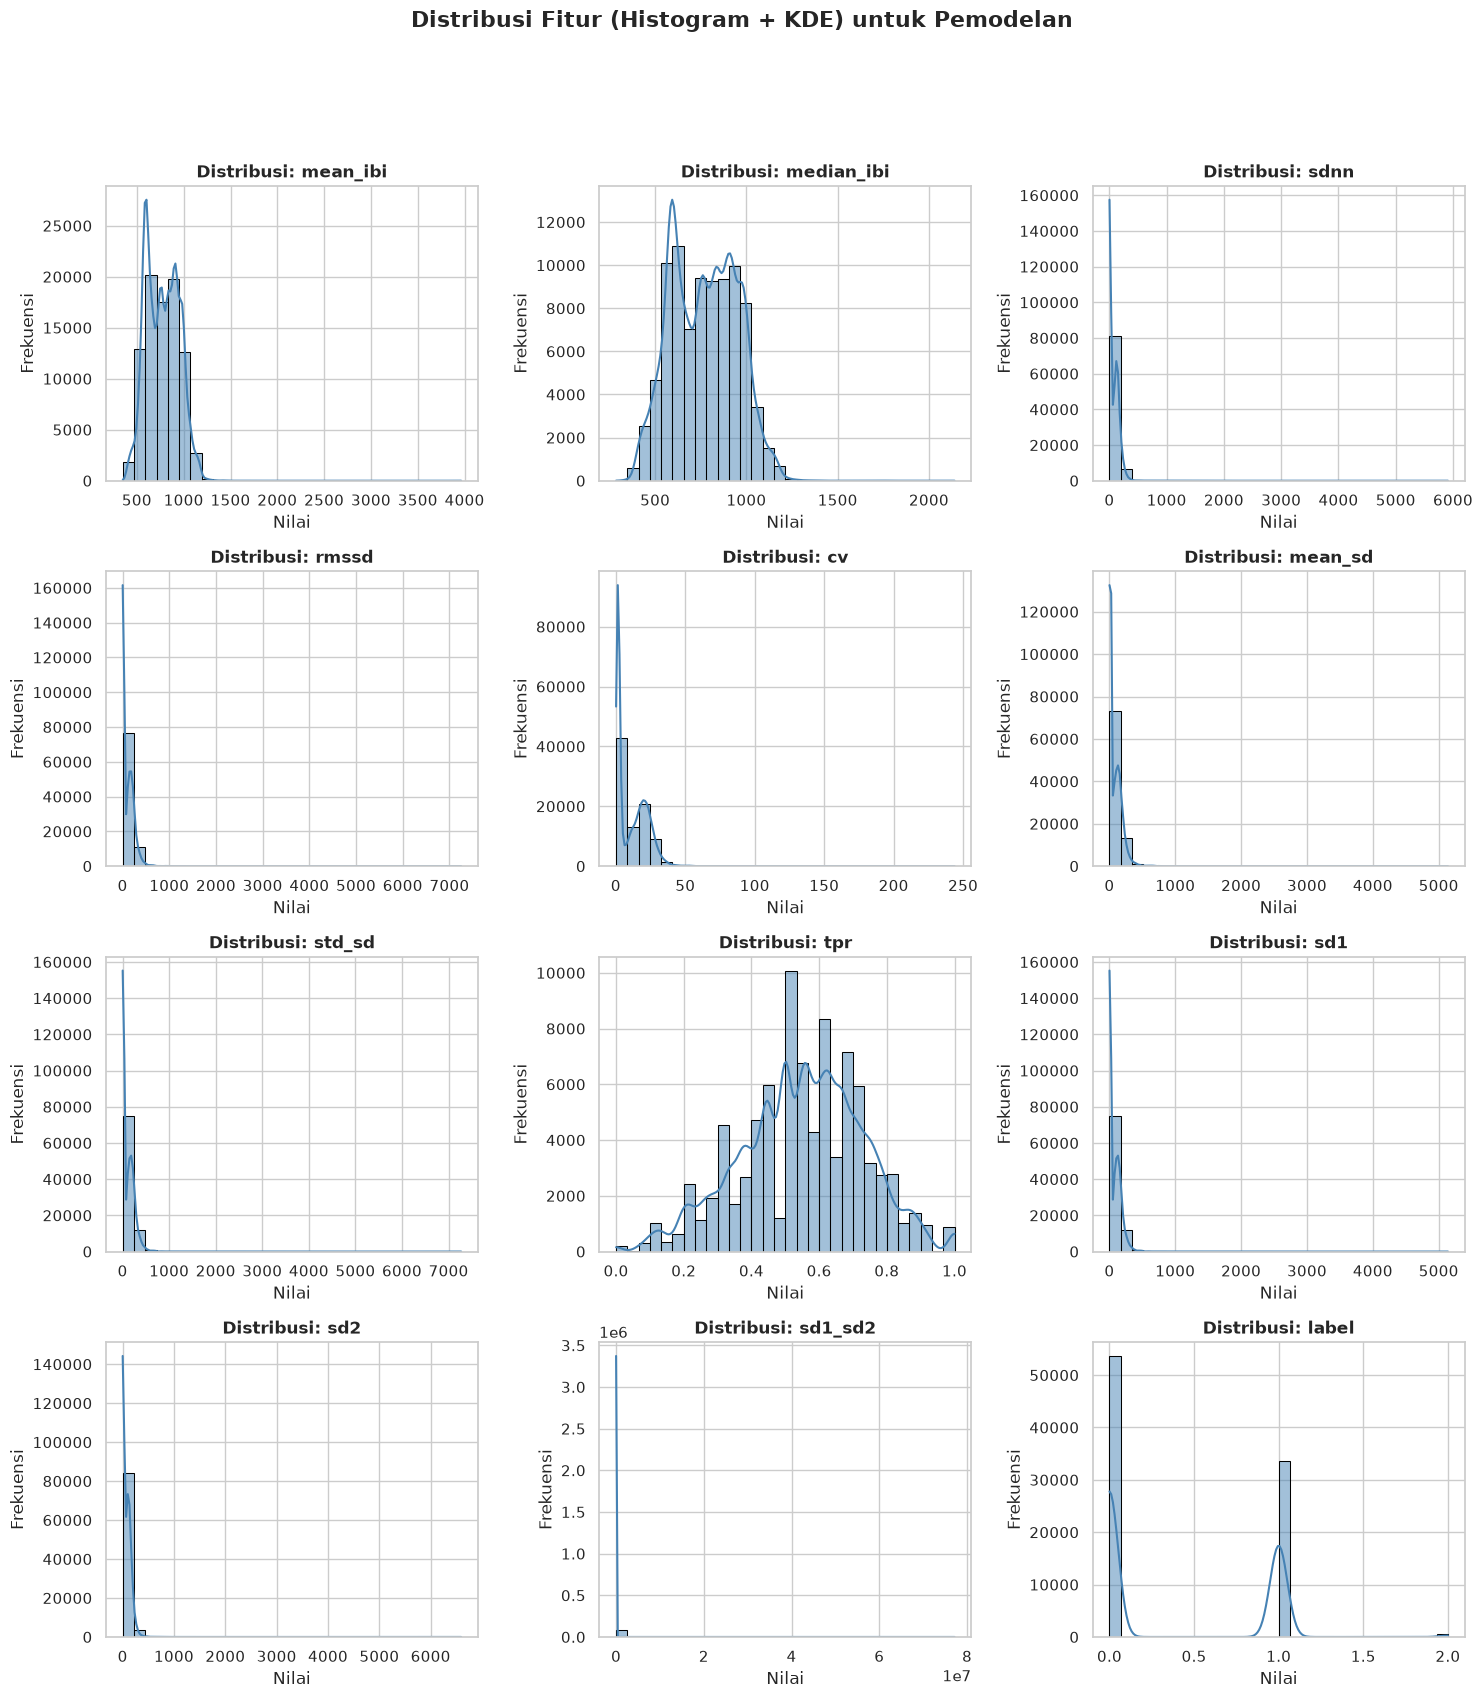

In [66]:
from scipy.stats import zscore
from IPython.display import display
import math

# Fitur yang digunakan untuk pemodelan (tanpa target label)
df_features = df[selected_cols]

sns.set_theme(style="whitegrid")

# 1. Menghitung dimensi grid (baris x kolom) secara dinamis
# Misal kita ingin membaginya menjadi 3 kolom agar rapi di layar
n_cols = len(df_features.columns)
ncols_grid = 3 
nrows_grid = math.ceil(n_cols / ncols_grid)

# 2. Inisialisasi Figure dan Axes (Object-Oriented API)
# Tinggi figure disesuaikan dinamis berdasarkan jumlah baris (4 inch per baris)
fig, axes = plt.subplots(nrows=nrows_grid, ncols=ncols_grid, figsize=(15, 4 * nrows_grid))

# Meratakan array axes dari 2D ke 1D agar mudah di-looping
axes = axes.flatten() 

# 3. Looping untuk menggambar histogram + KDE di setiap subplot
for i, col in enumerate(df_features.columns):
    sns.histplot(data=df_features, x=col, kde=True, bins=30, ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].set_title(f"Distribusi: {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frekuensi")
    axes[i].set_xlabel("Nilai")

# 4. Menghapus subplot yang kosong (jika jumlah fitur tidak habis dibagi 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Merapikan layout dan menampilkan hasil
plt.suptitle("Distribusi Fitur (Histogram + KDE) untuk Pemodelan", y=1.02 + (0.01 * nrows_grid), fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()



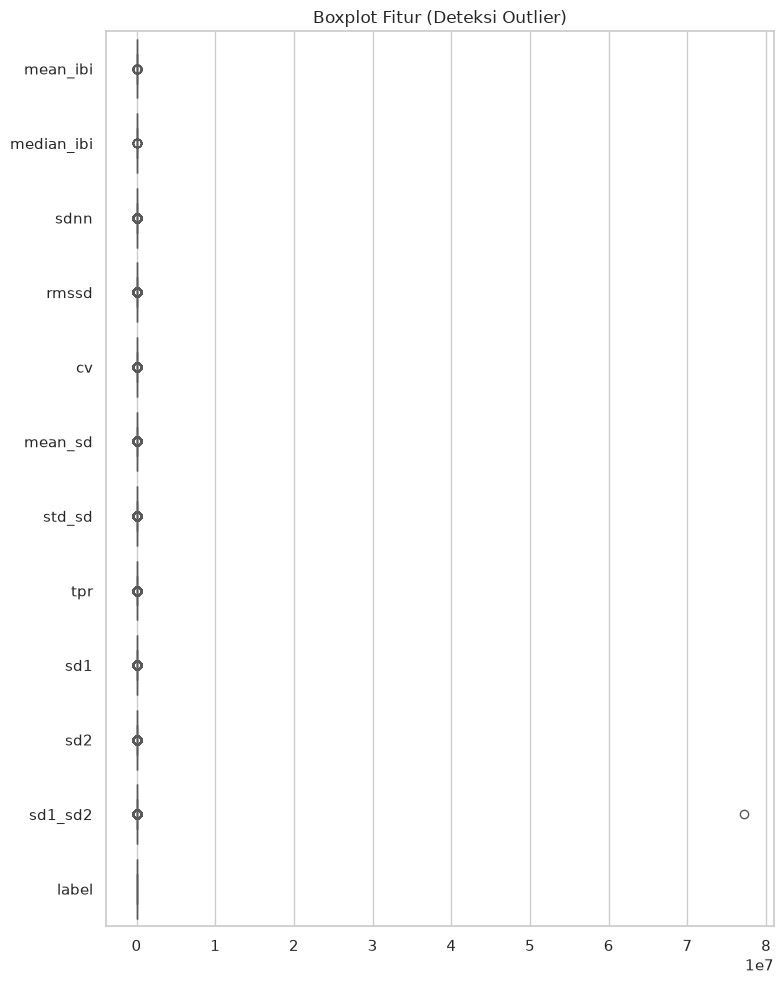

In [67]:
# 2. Mendeteksi Outlier Menggunakan Boxplot
plt.figure(figsize=(8, 10))
sns.boxplot(data=df_features, orient="h", palette="Set2")
plt.title("Boxplot Fitur (Deteksi Outlier)")
plt.tight_layout()
plt.show()

## `Preprocessing & modelling`

In [68]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer, RobustScaler,StandardScaler,FunctionTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report

# 1. Custom Transformer untuk IQR Clipping (Agar dapat masuk ke dalam Pipeline)
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_percentile=0.01, upper_percentile=0.99, factor=1.5):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        Q1 = X_df.quantile(self.lower_percentile)
        Q3 = X_df.quantile(self.upper_percentile)
        IQR = Q3 - Q1
        self.lower_bounds_ = Q1 - self.factor * IQR
        self.upper_bounds_ = Q3 + self.factor * IQR
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X)
        X_clipped = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_clipped

# Definisikan semua fitur HRV numerik yang akan diproses
numeric_features = ['mean_ibi', 'median_ibi', 'sdnn', 'rmssd', 'cv', 'mean_sd', 'std_sd', 'tpr', 'sd1', 'sd2', 'sd1_sd2']

# 2. Membuat Pipeline Khusus Numerik
numeric_transformer = Pipeline(steps=[
    ('clipper', IQRClipper()),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', RobustScaler())
])

# 3. Membuat ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'
)

# 4. Membuat Pipeline Final (Gabungan Preprocessing dan Model Klasifikasi)
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

# 5. Persiapan Data Mentah
# PASTIKAN df_hrv ADALAH DATAFRAME ASLI SEBELUM SCALING
df_fresh = pd.read_csv('dataset_hrv.csv')
X_raw = df_fresh[numeric_features].copy()
y = df_fresh['label'].copy()
groups = df_fresh['record'].copy() 

# 6. Pemisahan Data Berbasis Pasien (GroupSplit)
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in gss.split(X_raw, y, groups):
    X_train_final = X_raw.iloc[train_idx]
    y_train_final = y.iloc[train_idx]
    X_test_final = X_raw.iloc[test_idx]
    y_test_final = y.iloc[test_idx]
    break # Ambil split pertama saja untuk simulasi 80/20 train/test split

    
print("Sedang melatih Pipeline Utama dengan ColumnTransformer...")
clf_pipeline.fit(X_train_final, y_train_final)
y_pred_pipe = clf_pipeline.predict(X_test_final)

print("\n=== Hasil Klasifikasi Pipeline dengan ColumnTransformer ===")
print(classification_report(y_test_final, y_pred_pipe))


Sedang melatih Pipeline Utama dengan ColumnTransformer...

=== Hasil Klasifikasi Pipeline dengan ColumnTransformer ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     10939
           1       0.96      0.90      0.93      6770
           2       0.00      1.00      0.01         1

    accuracy                           0.94     17710
   macro avg       0.64      0.96      0.63     17710
weighted avg       0.96      0.94      0.95     17710



## coba2


In [69]:
# 1. Custom Transformer untuk IQR Clipping (Sama seperti sebelumnya)
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_percentile=0.01, upper_percentile=0.99, factor=1.5):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        Q1 = X_df.quantile(self.lower_percentile)
        Q3 = X_df.quantile(self.upper_percentile)
        IQR = Q3 - Q1
        self.lower_bounds_ = Q1 - self.factor * IQR
        self.upper_bounds_ = Q3 + self.factor * IQR
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X)
        X_clipped = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_clipped

# 2. Definisikan Kelompok Fitur
# mean, median, tpr menggunakan StandardScaler
std_features = ['mean_ibi', 'median_ibi', 'tpr']
# Sisanya MURNI menggunakan Log
log_features = ['sdnn', 'rmssd', 'cv', 'mean_sd', 'std_sd', 'sd1', 'sd2', 'sd1_sd2']
all_features = std_features + log_features

# 3. Membuat ColumnTransformer dengan dua cabang transformasi
branch_preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), std_features),
        ('log', FunctionTransformer(np.log1p, validate=False), log_features)
    ],
    remainder='passthrough'
)
logreg_pipeline = Pipeline(steps=[
    ('clipper', IQRClipper()), # Outlier dihapus dulu
    ('branching', branch_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

df_fresh = pd.read_csv('dataset_hrv.csv')
X_raw = df_fresh[all_features].copy()
y = df_fresh['label'].copy()
groups = df_fresh['record'].copy()

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in sgkf.split(X_raw, y, groups):
    X_train_logreg = X_raw.iloc[train_idx]
    y_train_logreg = y.iloc[train_idx]
    X_test_logreg = X_raw.iloc[test_idx]
    y_test_logreg = y.iloc[test_idx]
    break 

print("Melatih Logistic Regression Baseline...")
logreg_pipeline.fit(X_train_logreg, y_train_logreg)

y_pred_logreg = logreg_pipeline.predict(X_test_logreg)

print("\n=== Laporan Klasifikasi (Logistic Regression Baseline) ===")
print(classification_report(y_test_logreg, y_pred_logreg))


Melatih Logistic Regression Baseline...

=== Laporan Klasifikasi (Logistic Regression Baseline) ===
              precision    recall  f1-score   support

           0       0.98      0.92      0.94     10939
           1       0.96      0.85      0.90      6770
           2       0.00      1.00      0.00         1

    accuracy                           0.89     17710
   macro avg       0.64      0.92      0.61     17710
weighted avg       0.97      0.89      0.93     17710



In [70]:
print(df_features["label"].value_counts())

label
0    53655
1    33668
2      503
Name: count, dtype: int64


In [71]:
print(y_train_final.value_counts())
print(y_test_final.value_counts())

label
0    42716
1    26898
2      502
Name: count, dtype: int64
label
0    10939
1     6770
2        1
Name: count, dtype: int64
